In [ ]:
# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
sns.set_style('whitegrid')

In [87]:
df = pd.read_csv('raw_data_trades.csv')

In [7]:
df.shape

(23462, 16)

In [8]:
df.columns

Index(['trade_id', 'trader_id', 'persona', 'account_size',
       'balance_before_trade', 'balance_after_trade', 'trade_timestamp',
       'strategy_type', 'leverage_used', 'holding_minutes', 'stop_loss_used',
       'pnl', 'trade_outcome', 'overnight_position', 'capital_risked',
       'risk_per centage'],
      dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23462 entries, 0 to 23461
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trade_id              23462 non-null  object 
 1   trader_id             23462 non-null  object 
 2   persona               23462 non-null  object 
 3   account_size          23462 non-null  int64  
 4   balance_before_trade  23462 non-null  float64
 5   balance_after_trade   23462 non-null  float64
 6   trade_timestamp       23462 non-null  object 
 7   strategy_type         23462 non-null  object 
 8   leverage_used         23462 non-null  float64
 9   holding_minutes       23462 non-null  int64  
 10  stop_loss_used        23462 non-null  int64  
 11  pnl                   23462 non-null  float64
 12  trade_outcome         23462 non-null  object 
 13  overnight_position    23462 non-null  int64  
 14  capital_risked        23462 non-null  float64
 15  risk_per centage   

In [13]:
df.describe(include='all')

,trade_id,trader_id,persona,account_size,balance_before_trade,balance_after_trade,trade_timestamp,strategy_type,leverage_used,holding_minutes,stop_loss_used,pnl,trade_outcome,overnight_position,capital_risked,risk_per centage
count,23462,23462,23462,2.346200e+04,2.346200e+04,2.346200e+04,23462,23462,23462.000000,23462.000000,23462.000000,23462.000000,23462,23462.000000,23462.000000,23462.000000
unique,23462,200,4,NaN,NaN,NaN,12517,6,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,0632b329-98ba-431b-90f4-754b98c38e7a,TRADER_135,scalper_option_buyer,NaN,NaN,NaN,2025-01-01 10:01:00,Long Put,NaN,NaN,NaN,NaN,WIN,NaN,NaN,NaN
freq,1,543,8937,NaN,NaN,NaN,16,5732,NaN,NaN,NaN,NaN,12526,NaN,NaN,NaN
mean,NaN,NaN,NaN,7.651374e+05,7.398330e+05,7.393372e+05,NaN,NaN,3.811880,1075.039937,0.615890,-495.861859,NaN,0.466115,22686.907938,0.071666
std,NaN,NaN,NaN,7.937396e+05,8.398709e+05,8.407050e+05,NaN,NaN,2.082301,1419.045983,0.486395,6723.862717,NaN,0.498861,14913.038481,0.089466
min,NaN,NaN,NaN,2.013500e+04,-5.106548e+05,-5.106548e+05,NaN,NaN,1.000000,1.000000,0.000000,-48851.880000,NaN,0.000000,2171.260000,0.010000
25%,NaN,NaN,NaN,1.453200e+05,8.471098e+04,8.369424e+04,NaN,NaN,2.100000,26.000000,0.000000,-2839.015000,NaN,0.000000,11889.412500,0.021000
50%,NaN,NaN,NaN,3.144830e+05,3.423924e+05,3.425701e+05,NaN,NaN,3.300000,221.000000,1.000000,473.495000,NaN,0.000000,18449.475000,0.037600
75%,NaN,NaN,NaN,1.009611e+06,1.060574e+06,1.061390e+06,NaN,NaN,5.400000,1751.000000,1.000000,2202.480000,NaN,1.000000,28484.045000,0.084600


In [14]:
df.isnull().sum()

trade_id                0
trader_id               0
persona                 0
account_size            0
balance_before_trade    0
balance_after_trade     0
trade_timestamp         0
strategy_type           0
leverage_used           0
holding_minutes         0
stop_loss_used          0
pnl                     0
trade_outcome           0
overnight_position      0
capital_risked          0
risk_per centage        0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [30]:
trade_sum = df.groupby('persona').agg(sum = ('trade_id', 'count'))
trade_sum

,sum
persona,
disciplined_option_seller,7687
expiry_day_gambler,2412
scalper_option_buyer,8937
spread_trader,4426


<Axes: xlabel='trader_id', ylabel='holding_minutes'>

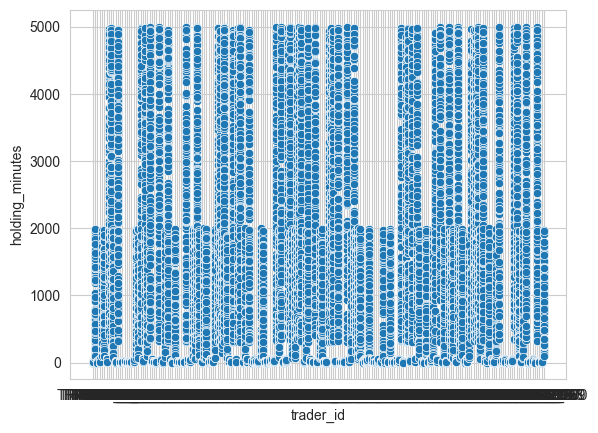

In [33]:
sns.scatterplot(
    x = 'trader_id',
    y = 'holding_minutes',
    data=df
)

In [88]:
df.columns

Index(['trade_id', 'trader_id', 'persona', 'account_size',
       'balance_before_trade', 'balance_after_trade', 'trade_timestamp',
       'strategy_type', 'leverage_used', 'holding_minutes', 'stop_loss_used',
       'pnl', 'trade_outcome', 'overnight_position', 'capital_risked',
       'risk_percentage'],
      dtype='object')

In [98]:
trader_features = df.groupby(["trader_id"]).agg(
    account_size=("account_size", "first"),
    final_balance=("balance_after_trade", "last"),
    total_trades=("trade_id", "count"),
    total_pnl=("pnl", "sum"),
    avg_pnl=("pnl", "mean"),
    win_rate=("trade_outcome", lambda x: (x == "WIN").mean()),
    avg_holding_minutes=("holding_minutes", "mean"),
    avg_leverage=("leverage_used", "mean"),
    avg_risk_pct=("risk_percentage", "mean"),
    stop_loss_usage_rate=("stop_loss_used", "mean"),
    overnight_position_rate=("overnight_position", "mean")
    
    ).reset_index()
trader_features['roi'] = trader_features['total_pnl'] / trader_features['account_size']
trader_features = trader_features.round(4)
trader_features

,trader_id,account_size,final_balance,total_trades,total_pnl,avg_pnl,win_rate,avg_holding_minutes,avg_leverage,avg_risk_pct,stop_loss_usage_rate,overnight_position_rate,roi
0,TRADER_1,140844,6040.34,23,-134803.66,-5861.0287,0.2609,9.6522,7.4435,0.2541,0.2174,0.0000,-0.9571
1,TRADER_10,613287,695269.02,95,81982.02,862.9686,0.6211,1033.4526,2.5240,0.0246,0.8211,0.8000,0.1337
2,TRADER_100,90035,-119039.80,36,-209074.80,-5807.6333,0.2500,10.8056,6.8461,0.2325,0.2778,0.0000,-2.3222
3,TRADER_101,995246,1052602.33,95,57356.33,603.7508,0.6105,1142.7474,2.5039,0.0250,0.8105,0.7684,0.0576
4,TRADER_102,778892,875334.14,93,96442.14,1037.0123,0.6882,979.2688,2.4841,0.0257,0.7634,0.7849,0.1238
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,TRADER_95,926350,929808.19,94,3458.19,36.7893,0.4894,1007.1489,2.5357,0.0254,0.8298,0.7447,0.0037
196,TRADER_96,2486184,2567392.43,146,81208.43,556.2221,0.6712,2648.7603,1.9968,0.0193,0.9110,0.9041,0.0327
197,TRADER_97,131116,2524.12,111,-128591.88,-1158.4854,0.4144,33.9009,4.9905,0.0776,0.4595,0.0811,-0.9807
198,TRADER_98,81697,-74355.03,28,-156052.03,-5573.2868,0.2500,10.4643,7.6996,0.2319,0.3571,0.0000,-1.9101


In [99]:
trader_features.corr(numeric_only=True)

,account_size,final_balance,total_trades,total_pnl,avg_pnl,win_rate,avg_holding_minutes,avg_leverage,avg_risk_pct,stop_loss_usage_rate,overnight_position_rate,roi
account_size,1.000000,0.991579,0.208487,0.623350,0.528776,0.753213,0.877582,-0.717744,-0.591665,0.751495,0.760537,0.479290
final_balance,0.991579,1.000000,0.174898,0.719362,0.579508,0.802500,0.903748,-0.770106,-0.642791,0.805031,0.818319,0.542297
total_trades,0.208487,0.174898,1.000000,-0.062255,0.502376,0.371332,0.186878,-0.354319,-0.477465,0.247163,0.112917,0.273394
total_pnl,0.623350,0.719362,-0.062255,1.000000,0.662825,0.805419,0.749661,-0.800070,-0.707608,0.829912,0.861643,0.703579
avg_pnl,0.528776,0.579508,0.502376,0.662825,1.000000,0.872222,0.599985,-0.851879,-0.829062,0.792878,0.732022,0.725411
win_rate,0.753213,0.802500,0.371332,0.805419,0.872222,1.000000,0.857971,-0.945828,-0.854659,0.930639,0.914189,0.702888
avg_holding_minutes,0.877582,0.903748,0.186878,0.749661,0.599985,0.857971,1.000000,-0.823650,-0.668579,0.868893,0.886968,0.546450
avg_leverage,-0.717744,-0.770106,-0.354319,-0.800070,-0.851879,-0.945828,-0.823650,1.000000,0.941015,-0.969252,-0.939611,-0.724259
avg_risk_pct,-0.591665,-0.642791,-0.477465,-0.707608,-0.829062,-0.854659,-0.668579,0.941015,1.000000,-0.873360,-0.795943,-0.716758
stop_loss_usage_rate,0.751495,0.805031,0.247163,0.829912,0.792878,0.930639,0.868893,-0.969252,-0.873360,1.000000,0.965977,0.695708


In [112]:
top_traders = trader_features.nlargest(n=5,columns=['total_pnl'])
top_traders

,trader_id,account_size,final_balance,total_trades,total_pnl,avg_pnl,win_rate,avg_holding_minutes,avg_leverage,avg_risk_pct,stop_loss_usage_rate,overnight_position_rate,roi
155,TRADER_59,1836978,1955391.50,157,118413.50,754.2261,0.7197,2651.5796,2.0371,0.0199,0.9299,0.9236,0.0645
178,TRADER_8,1152402,1266654.93,161,114252.93,709.6455,0.7764,2525.8012,1.9640,0.0196,0.9006,0.8758,0.0991
162,TRADER_65,1629718,1741846.72,146,112128.72,768.0049,0.7534,2608.8493,2.0410,0.0206,0.9041,0.8630,0.0688
70,TRADER_162,2530791,2639977.03,149,109186.03,732.7921,0.7517,2766.7450,1.9616,0.0191,0.8993,0.9060,0.0431
193,TRADER_93,2424249,2533112.22,145,108863.22,750.7808,0.7310,2694.0759,1.9759,0.0193,0.9172,0.8897,0.0449


In [115]:
df['trade_timestamp'] = pd.to_datetime(df['trade_timestamp'])
df['day_of_week'] = df['trade_timestamp'].dt.day_name()
df.groupby("day_of_week")["pnl"].mean()

day_of_week
Friday        -75.022001
Monday        -22.664053
Thursday     -912.803491
Tuesday       149.102813
Wednesday   -1103.476348
Name: pnl, dtype: float64